In [1]:
import numpy as np

import os

from nbodykit.lab import *
from nbodykit import setup_logging, style

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import SymLogNorm

import scipy.integrate as integrate

from astropy.cosmology import FlatLambdaCDM

In [2]:
from baryonification.baryonification.params import par
from baryonification.baryonification.cosmo import cosmo
from baryonification.baryonification.displ import displace
from baryonification.baryonification.halo_displ import displace_haloes

from miniramses.utils.py.miniramses import rd_info
from miniramses.utils.py.miniramses import Info

In [3]:
#initialise parameters

par = par()

if par.code.multicomp:
    comp = 'multicomp' #'multicomp' or 'singlecomp'
else:
    comp = 'singlecomp'

size = par.code.size #'big' or 'small'

par.files.transfct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/CDM_PLANCK_tk.dat"
par.files.cosmofct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/cosmofct.dat"
par.files.displfct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/displfct.dat"
par.files.halofile_format = "ramses"
par.files.partfile_format = "ramses"
if size == 'big':
    par.files.partfile_in = "/scratch/gpfs/rt3504/bigbox/output_00011"
    par.files.halofile_in = "/scratch/gpfs/rt3504/bigbox/output_00011"
elif size == 'small':
    par.files.halofile_in = "/home/jamesdr/scratch/smallbox/output_00011"
    par.files.partfile_in = "/home/jamesdr/scratch/smallbox/output_00011"
par.files.partfile_out = "/home/jamesdr/usrp2024/{}_{}/partfile_out.std".format(comp,size)
par.files.halofile_out = "/home/jamesdr/usrp2024/{}_{}/halofile_out.std".format(comp,size)

Found 2097152 particles


In [4]:
import re

# Extracting the path using regular expression
path = re.match(r'(.*/{}box/)'.format(size), par.files.partfile_in).group(1)

# Extracting the number as an integer
nout = int(re.match(r'.*/output_(\d+)', par.files.partfile_in).group(1))

i = rd_info(nout, path=path)
unit_l = i.unit_l
unit_d = i.unit_d #g/cm^3
unit_m = unit_d * (unit_l)**3.0
unit_m_in_Msol_per_h = unit_m / (1.989e33) * par.cosmo.h0
unit_l_in_Mpc_per_h = unit_l / (3.086e24) * par.cosmo.h0

In [5]:
from baryonification.baryonification.io import read_nbody_file

In [6]:
p_header, non_displaced_dm = read_nbody_file(par)

Found 2097152 particles


In [7]:
def read_displaced_particles(file):

    Lbox   = unit_l / (3.086e24) * par.cosmo.h0
    N_chunk = 1
    L_chunk = Lbox/N_chunk
    
    Om = i.omega_m
    z  = par.cosmo.z
    
    f = open(file, 'r')

    #header
    p_header_dt = np.dtype([('a','>d'),('Npart','>i'),('dim','>i'),('Ngas','>i'),('Ndm','>i'),('Nstar','>i'),('buffer','>i')])
    p_header = np.fromfile(f, dtype=p_header_dt, count=1, sep='')
    
    #gas
    p_gas_dt = np.dtype([('mass','>f4'),('x', '>f4'),('y', '>f4'),('z', '>f4'),('vx', '>f4'),('vy', '>f4'),\
                               ('vz', '>f4'),('rho','>f4'),('temp','>f4'),('hsmooth','>f4'),('metals','>f4'),('phi','>f4')])
    p_gas = np.fromfile(f, dtype=p_gas_dt, count=int(p_header['Ngas']), sep='')
    
    #dm
    p_dm_dt   = np.dtype([('mass','>f4'),("x",'>f4'),("y",'>f4'),("z",'>f4'),("vx",'>f4'),("vy",'>f4'),("vz",'>f4'),\
                                ("eps",'>f4'),("phi",'>f4')])
    p_dm = np.fromfile(f, dtype=p_dm_dt, count=int(p_header['Ndm']), sep='')
    
    #stars
    p_star_dt = np.dtype([('mass','>f4'),('x', '>f4'),('y', '>f4'),('z', '>f4'),('vx', '>f4'),('vy', '>f4'),\
                                 ('vz', '>f4'),('metals','>f4'),('tform','>f4'),('eps','>f4'),('phi','>f4')])
    p_star = np.fromfile(f, dtype=p_star_dt, count=int(p_header['Nstar']), sep='')

    #convert to Mpc/h
    p_gas['x']=Lbox*(p_gas['x']+0.5)
    p_gas['y']=Lbox*(p_gas['y']+0.5)
    p_gas['z']=Lbox*(p_gas['z']+0.5)
    p_dm['x']=Lbox*(p_dm['x']+0.5)
    p_dm['y']=Lbox*(p_dm['y']+0.5)
    p_dm['z']=Lbox*(p_dm['z']+0.5)
    p_star['x']=Lbox*(p_star['x']+0.5)
    p_star['y']=Lbox*(p_star['y']+0.5)
    p_star['z']=Lbox*(p_star['z']+0.5)

    #convert to Mstar/h
    print("Om = ", np.sum(p_gas['mass'])+np.sum(p_dm['mass'])+np.sum(p_star['mass']))
    p_gas['mass'] = p_gas['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
    p_dm['mass'] = p_dm['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
    p_star['mass'] = p_star['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
        
    print('Reading tipsy-file done!')
    
    #split particles into chunks
    p_gas_list   = []
    for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
        x_max = x_min + L_chunk
        if (x_max == Lbox):
            x_max = 1.00001*x_max
        for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            y_max =y_min + L_chunk
            if (y_max == Lbox):
                    y_max = 1.00001*y_max
            for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                z_max = z_min + L_chunk
                if (z_max == Lbox):
                        z_max = 1.00001*z_max
                ID_gas = np.where((p_gas['x']>=x_min) & (p_gas['x']<x_max) & (p_gas['y']>=y_min) & (p_gas['y']<y_max) & (p_gas['z']>=z_min) & (p_gas['z']<z_max))
                p_gas_list += [p_gas[ID_gas]]
                
    #split particles into chunks
    p_dm_list   = []
    for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
        x_max = x_min + L_chunk
        if (x_max == Lbox):
            x_max = 1.00001*x_max
        for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            y_max =y_min + L_chunk
            if (y_max == Lbox):
                    y_max = 1.00001*y_max
            for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                z_max = z_min + L_chunk
                if (z_max == Lbox):
                        z_max = 1.00001*z_max
                ID_dm = np.where((p_dm['x']>=x_min) & (p_dm['x']<x_max) & (p_dm['y']>=y_min) & (p_dm['y']<y_max) & (p_dm['z']>=z_min) & (p_dm['z']<z_max))
                p_dm_list += [p_dm[ID_dm]]
                
    #split particles into chunks
    p_star_list   = []
    for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
        x_max = x_min + L_chunk
        if (x_max == Lbox):
            x_max = 1.00001*x_max
        for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            y_max =y_min + L_chunk
            if (y_max == Lbox):
                    y_max = 1.00001*y_max
            for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                z_max = z_min + L_chunk
                if (z_max == Lbox):
                        z_max = 1.00001*z_max
                ID_star = np.where((p_star['x']>=x_min) & (p_star['x']<x_max) & (p_star['y']>=y_min) & (p_star['y']<y_max) & (p_star['z']>=z_min) & (p_star['z']<z_max))
                p_star_list += [p_star[ID_star]]
    
    return p_header, p_gas_list, p_dm_list, p_star_list

In [8]:
p_displaced_header, displaced_gas, displaced_dm, displaced_stars = read_displaced_particles("/home/jamesdr/usrp2024/{}_{}/partfile_out.std".format(comp,size))

Om =  0.27378902
Reading tipsy-file done!


In [9]:
#First we do gas, particle pasting

Om0 = 0.308
Ob0 = 0.0486
cosmo = FlatLambdaCDM(H0=67.74, Om0 = Om0, Ob0 = Ob0, Tcmb0 = 2.7255, Neff = 3.046) #Neutrino mass is 0 by default
c_km = 3e5 #km/s
sigmat = 6.98426e-74 * (cosmo.h)**2 #(Mpc/h)^2
m_p = 1.67262192e-27/1.989e+30 * cosmo.h #Msol/h
if size == 'big':
    bins = 1000
elif size == 'small':
    bins = 500

electrons_per_particle = displaced_gas[0]['mass'][0] / m_p
Mpc_per_pixel = unit_l_in_Mpc_per_h/bins

In [10]:
weights = electrons_per_particle * sigmat / c_km * displaced_gas[0]['vz'] / ((Mpc_per_pixel)**2.0)

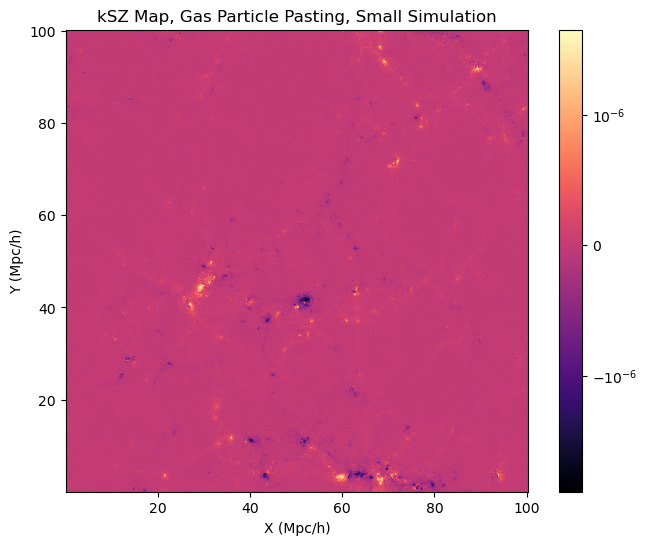

In [11]:
gas_hist, gas_xedges, gas_yedges = np.histogram2d(displaced_gas[0]['x'],displaced_gas[0]['y'],density=False, weights=weights,bins=bins)
gas_hist = gas_hist.T

norm = SymLogNorm(linthresh=1.0e-6, linscale=1.0, vmin=np.min(gas_hist), vmax=np.max(gas_hist))

# Plotting in log-log scale
plt.figure(figsize=(8, 6))
plt.imshow(gas_hist, interpolation='nearest', origin='lower', extent=[gas_xedges[0], gas_xedges[-1], gas_yedges[0], gas_yedges[-1]], norm=norm, cmap='magma')

# Add colorbar
plt.colorbar()

# Adding labels and title
plt.xlabel('X (Mpc/h)')
plt.ylabel('Y (Mpc/h)')

if size=='small':
    plt.title(r"kSZ Map, Gas Particle Pasting, Small Simulation")
if size=='big':
    plt.title(r"kSZ Map, Gas Particle Pasting, Large Simulation")

plt.savefig(os.path.join('{}_{}'.format(comp, size), 'gas_pp.pdf'), bbox_inches='tight')

plt.show()

In [12]:
#Now we do the same thing for the DMO simulations, applying an Ob/Om correction factor

baryon_correction_factor = Ob0/Om0

electrons_per_dm_particle = non_displaced_dm[0]['mass'][0] / m_p

dm_weights = baryon_correction_factor * electrons_per_dm_particle * sigmat / c_km * non_displaced_dm[0]['vz'] / ((Mpc_per_pixel)**2.0);

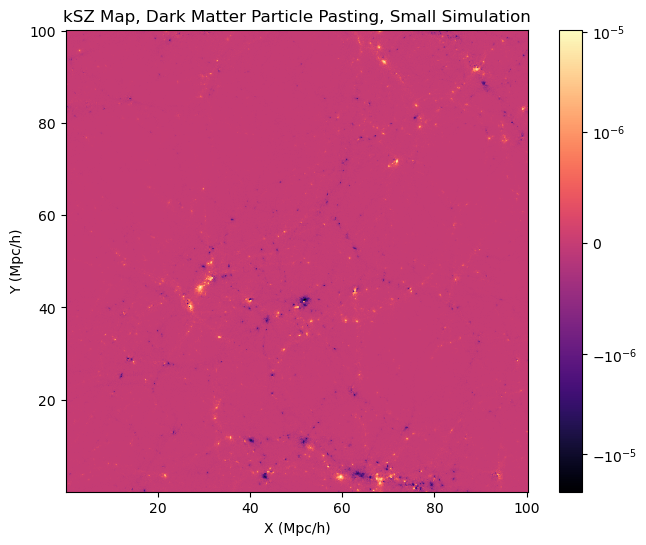

In [13]:
dm_hist, dm_xedges, dm_yedges = np.histogram2d(non_displaced_dm[0]['x'],non_displaced_dm[0]['y'],density=False, weights=dm_weights,bins=bins)
dm_hist = dm_hist.T

norm = SymLogNorm(linthresh=1.0e-6, linscale=1.0, vmin=np.min(dm_hist), vmax=np.max(dm_hist))

# Plotting in log-log scale
plt.figure(figsize=(8, 6))
plt.imshow(dm_hist, interpolation='nearest', origin='lower', extent=[dm_xedges[0], dm_xedges[-1], dm_yedges[0], dm_yedges[-1]], norm=norm, cmap='magma')

# Add colorbar
plt.colorbar()

# Adding labels and title
plt.xlabel('X (Mpc/h)')
plt.ylabel('Y (Mpc/h)')

if size=='small':
    plt.title(r"kSZ Map, Dark Matter Particle Pasting, Small Simulation")
if size=='big':
    plt.title(r"kSZ Map, Dark Matter Particle Pasting, Large Simulation")

plt.savefig(os.path.join('{}_{}'.format(comp, size), 'dm_pp.pdf'), bbox_inches='tight')

plt.show()

In [14]:
#Now we do the Osato halo pasting method

from baryonification.baryonification.io import read_halo_file
haloes = read_halo_file(par)

Found 2226 clumps
Converting r200b, M200b, and c200b to r200c, M200c, and c200c
Done!


/home/jamesdr/.conda/envs/usrp2024/lib/python3.8/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


In [15]:
from scipy import spatial

gas_tree = spatial.cKDTree(list(zip(displaced_gas[0]['x'],displaced_gas[0]['y'],displaced_gas[0]['z'])), leafsize=100, boxsize=unit_l_in_Mpc_per_h)
dm_tree = spatial.cKDTree(list(zip(non_displaced_dm[0]['x'],non_displaced_dm[0]['y'],non_displaced_dm[0]['z'])), leafsize=100, boxsize=unit_l_in_Mpc_per_h)

In [16]:
iphalo = np.zeros(len(displaced_gas[0]['x']))
#This loop finds each particle, and tells you the halo it belongs to
for i in range(len(haloes[0]['Mvir'])):
    ip   = np.array(gas_tree.query_ball_point((haloes[0]['x'][i],haloes[0]['y'][i],haloes[0]['z'][i]), haloes[0]['rvir'][i]))
    if len(ip)>0:
        iphalo[ip] = i

In [17]:
#We go halo by halo, assigning every particle in each halo the velocity of that halo

weights_Osato = np.zeros(len(displaced_gas[0]['x']));

weights_haloes = electrons_per_particle * sigmat / c_km * haloes[0]['vz'] / ((Mpc_per_pixel)**2.0);

In [18]:
#This loop takes every gas particle, finds the halo it belongs to,
#and assigns to it the weight of that halo
for i in range(len(displaced_gas[0]['x'])):
    iphaloi = iphalo[i].astype(int)
    if iphaloi == 0:
        pass
    else:
        weights_Osato[i] += weights_haloes[iphaloi]

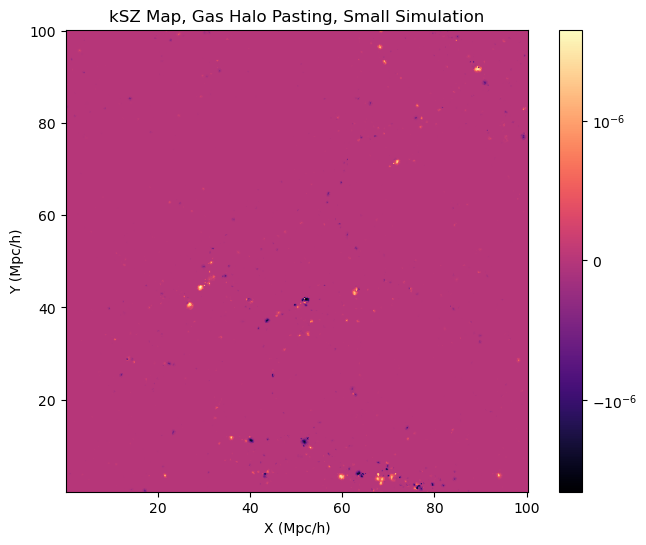

In [19]:
gas_hist_Osato, gas_xedges_Osato, gas_yedges_Osato = np.histogram2d(displaced_gas[0]['x'],displaced_gas[0]['y'],density=False, weights=weights_Osato,bins=bins)
gas_hist_Osato = gas_hist_Osato.T

norm = SymLogNorm(linthresh=1.0e-6, linscale=1.0, vmin=np.min(gas_hist_Osato), vmax=np.max(gas_hist_Osato))

# Plotting in log-log scale
plt.figure(figsize=(8, 6))
plt.imshow(gas_hist_Osato, interpolation='nearest', origin='lower', extent=[gas_xedges_Osato[0], gas_xedges_Osato[-1], gas_yedges_Osato[0], gas_yedges_Osato[-1]], norm=norm, cmap='magma')

# Add colorbar
plt.colorbar()

# Adding labels and title
plt.xlabel('X (Mpc/h)')
plt.ylabel('Y (Mpc/h)')

if size=='small':
    plt.title(r"kSZ Map, Gas Halo Pasting, Small Simulation")
if size=='big':
    plt.title(r"kSZ Map, Gas Halo Pasting, Large Simulation")

plt.savefig(os.path.join('{}_{}'.format(comp, size), 'gas_hp.pdf'), bbox_inches='tight')

plt.show()

In [20]:
#Now doing the same for non-dispalced dm

iphalo = np.zeros(len(non_displaced_dm[0]['x']))
#This loop finds each particle, and tells you the halo it belongs to
for i in range(len(haloes[0]['Mvir'])):
    ip   = np.array(dm_tree.query_ball_point((haloes[0]['x'][i],haloes[0]['y'][i],haloes[0]['z'][i]), haloes[0]['rvir'][i]))
    if len(ip)>0:
        iphalo[ip] = i

In [21]:
#We go halo by halo, assigning every particle in each halo the velocity of that halo

weights_Osato = np.zeros(len(non_displaced_dm[0]['x']));

weights_haloes = electrons_per_particle * sigmat / c_km * haloes[0]['vz'] / ((Mpc_per_pixel)**2.0);

In [22]:
#This loop takes every gas particle, finds the halo it belongs to,
#and assigns to it the weight of that halo
for i in range(len(non_displaced_dm[0]['x'])):
    iphaloi = iphalo[i].astype(int)
    if iphaloi == 0:
        pass
    else:
        weights_Osato[i] += weights_haloes[iphaloi]

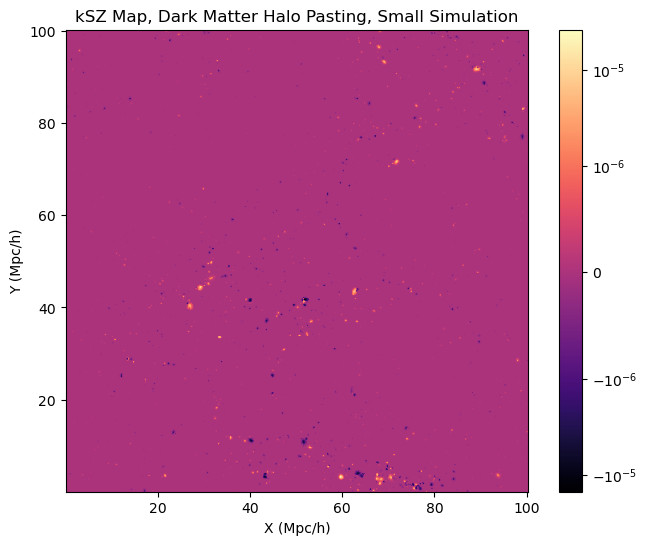

In [23]:
dm_hist_Osato, dm_xedges_Osato, dm_yedges_Osato = np.histogram2d(non_displaced_dm[0]['x'],non_displaced_dm[0]['y'],density=False, weights=weights_Osato,bins=bins)
dm_hist_Osato = dm_hist_Osato.T

norm = SymLogNorm(linthresh=1.0e-6, linscale=1.0, vmin=np.min(dm_hist_Osato), vmax=np.max(dm_hist_Osato))

# Plotting in log-log scale
plt.figure(figsize=(8, 6))
plt.imshow(dm_hist_Osato, interpolation='nearest', origin='lower', extent=[dm_xedges_Osato[0], dm_xedges_Osato[-1], dm_yedges_Osato[0], dm_yedges_Osato[-1]], norm=norm, cmap='magma')

# Add colorbar
plt.colorbar()

# Adding labels and title
plt.xlabel('X (Mpc/h)')
plt.ylabel('Y (Mpc/h)')

if size=='small':
    plt.title(r"kSZ Map, Dark Matter Halo Pasting, Small Simulation")
if size=='big':
    plt.title(r"kSZ Map, Dark Matter Halo Pasting, Large Simulation")

plt.savefig(os.path.join('{}_{}'.format(comp, size), 'dm_hp.pdf'), bbox_inches='tight')

plt.show()

In [24]:
np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'gas_pp.npy'), gas_hist)
np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'gas_pp_xedges.npy'), gas_xedges)
np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'gas_pp_yedges.npy'), gas_yedges)

np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'dm_pp.npy'), dm_hist)
np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'dm_pp_xedges.npy'), dm_xedges)
np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'dm_pp_yedges.npy'), dm_yedges)

np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'gas_hp.npy'), gas_hist_Osato)
np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'gas_hp_xedges.npy'), gas_xedges_Osato)
np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'gas_hp_yedges.npy'), gas_yedges_Osato)

np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'dm_hp.npy'), dm_hist_Osato)
np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'dm_hp_xedges.npy'), dm_xedges_Osato)
np.save(os.path.join('/home/jamesdr/usrp2024/results_{}_{}'.format(comp,size), 'dm_hp_yedges.npy'), dm_yedges_Osato)